In [1]:
import time, gc
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit

from GLMM import GLMM, EPS

%matplotlib inline
pd.set_option("display.max_columns", 100)


## Simulate data


In [2]:
DEFAULT_ALPHA = (-5, 0.7, 0.3, -0.2, 0.5, -0.35, 0.25, -0.15, 0.4, -0.3)


def simulate_logistic_glmm(
    n_obs=30_000,
    n_random_effects=200,
    n_fixed_covariates=10,
    alpha=None,
    alpha_intercept=-5.0,
    sigma_b=3.0,
    seed=1,
):
    rng = np.random.default_rng(seed)

    fixed_parts = [np.ones(n_obs)]
    fixed_names = ["intercept"]
    for j in range(n_fixed_covariates):
        xj = rng.normal(size=n_obs)
        xj = (xj - xj.mean()) / max(float(xj.std(ddof=1)), EPS)
        fixed_parts.append(xj)
        fixed_names.append(f"w{j + 1}")
    W = np.column_stack(fixed_parts)

    if alpha is None:
        alpha_arr = np.zeros(W.shape[1], dtype=float)
        n_fill = min(W.shape[1], len(DEFAULT_ALPHA))
        alpha_arr[:n_fill] = DEFAULT_ALPHA[:n_fill]
        if alpha_intercept is not None:
            alpha_arr[0] = float(alpha_intercept)
    else:
        alpha_arr = np.asarray(alpha, dtype=float)
    if alpha_arr.shape != (W.shape[1],):
        raise ValueError(f"alpha must have shape ({W.shape[1]},), got {alpha_arr.shape}.")

    group = np.arange(n_obs, dtype=int) % n_random_effects
    rng.shuffle(group)
    X = np.zeros((n_obs, n_random_effects), dtype=float)
    X[np.arange(n_obs), group] = 1.0

    beta = rng.normal(loc=0.0, scale=sigma_b, size=n_random_effects)
    eta = W @ alpha_arr + X @ beta
    prob = expit(eta)
    y = rng.binomial(1, prob, size=n_obs).astype(float)

    df_dict = {
        "y": y.astype(int),
        "eta_true": eta,
        "p_true": prob,
        "group": group,
    }
    for j, name in enumerate(fixed_names):
        df_dict[name] = W[:, j]

    truth = {
        "alpha": alpha_arr,
        "beta": beta,
        "sigma_b": float(sigma_b),
        "eta": eta,
        "p": prob,
        "n_random_effects": int(n_random_effects),
        "group": group,
    }
    return {
        "df": pd.DataFrame(df_dict),
        "W": W,
        "X": X,
        "y": y,
        "truth": truth,
    }


In [3]:
N_OBS_VALUES = [30_000]
N_REPS = 100
BASE_SEED = 1
N_RANDOM_EFFECTS = 200
N_FIXED_COVARIATES = 10
ALPHA_INTERCEPT = -5.0
SIGMA_B_TRUE = 3.0
TEST_FRACTION = 0.2

METHODS = ["Laplace", "PQL", "Pyro"]
RUN_FULL_SIMULATION = False
RAW_RESULTS_PATH = "/import/home2/share/ztanag/Tutorial_code/VI_simu/GLMM/results/glmm_simulation_raw.csv"

LAPLACE_MAXITER = 80
PQL_ITER = 20
PQL_TOL = 1e-5
PYRO_VI_STEPS = 1500
PYRO_VI_LR = 0.015
PYRO_VI_NUM_PARTICLES = 1
VI_BATCH_SIZE = 10_000
DEVICE = None

print(
    f"n_obs_values={N_OBS_VALUES}, reps={N_REPS}, "
    f"p_random={N_RANDOM_EFFECTS}, q_fixed={N_FIXED_COVARIATES}, sigma_b={SIGMA_B_TRUE}"
)


n_obs_values=[30000], reps=100, p_random=200, q_fixed=10, sigma_b=3.0


## Define one-run


In [4]:
def split_train_test(y, seed, test_fraction):
    if not 0.0 <= test_fraction < 1.0:
        raise ValueError("test_fraction must be in [0, 1).")
    if test_fraction == 0.0:
        train_idx = np.arange(len(y))
        test_idx = np.array([], dtype=int)
        return train_idx, test_idx

    split_rng = np.random.default_rng(seed + 2026)
    indices = split_rng.permutation(len(y))
    n_test = int(round(test_fraction * len(indices)))
    test_idx = np.sort(indices[:n_test])
    train_idx = np.sort(indices[n_test:])
    return train_idx, test_idx


def run_one_rep(n_obs, rep_id, seed):
    data = simulate_logistic_glmm(
        n_obs=n_obs,
        n_random_effects=N_RANDOM_EFFECTS,
        n_fixed_covariates=N_FIXED_COVARIATES,
        alpha_intercept=ALPHA_INTERCEPT,
        sigma_b=SIGMA_B_TRUE,
        seed=seed,
    )
    W, X, y, truth = data["W"], data["X"], data["y"], data["truth"]
    train_idx, test_idx = split_train_test(y, seed, TEST_FRACTION)

    W_train, X_train, y_train = W[train_idx], X[train_idx], y[train_idx]
    W_test = X_test = y_test = None
    if test_idx.size:
        W_test, X_test, y_test = W[test_idx], X[test_idx], y[test_idx]

    model = GLMM(
        laplace_maxiter=LAPLACE_MAXITER,
        pql_iter=PQL_ITER,
        pql_tol=PQL_TOL,
        pyro_vi_steps=PYRO_VI_STEPS,
        pyro_vi_lr=PYRO_VI_LR,
        pyro_vi_num_particles=PYRO_VI_NUM_PARTICLES,
        vi_batch_size=VI_BATCH_SIZE,
        device=DEVICE,
    )
    start_alpha = model._fit_logistic_fixed_start(W_train, y_train)
    start_sigma_b = 1.0

    runners = {
        "Laplace": lambda: model.Laplace(
            W_train,
            X_train,
            y_train,
            start_alpha=start_alpha,
            start_log_sigma=math.log(start_sigma_b),
        ),
        "PQL": lambda: model.PQL(
            W_train,
            X_train,
            y_train,
            start_alpha=start_alpha,
            verbose=False,
        ),
        "Pyro": lambda: model.PyroVI(
            W_train,
            X_train,
            y_train,
            seed=seed,
            start_alpha=start_alpha,
            start_sigma_b=start_sigma_b,
        ),
    }

    rows = []
    for method in METHODS:
        try:
            fit, elapsed = model._time_fit(runners[method])
            row = model.summarize_fit(
                method,
                fit,
                truth,
                W_train,
                X_train,
                y_train,
                elapsed,
                W_test=W_test,
                X_test=X_test,
                y_test=y_test,
            )
        except Exception as exc:
            print(f"[WARN] {method} failed at n_obs={n_obs}, rep={rep_id}: {exc}")
            row = {
                "method": method,
                "time_sec": np.nan,
                "alpha_rmse": np.nan,
                "beta_rmse": np.nan,
                "beta_l2_error": np.nan,
                "beta_corr": np.nan,
                "sigma_abs_error": np.nan,
                "sigma_error": np.nan,
                "sigma_hat": np.nan,
                "train_log_loss": np.nan,
                "train_brier_score": np.nan,
                "test_brier_score": np.nan,
                "test_auc": np.nan,
                "error": repr(exc),
            }

        group = np.asarray(truth["group"], dtype=int)
        group_events = np.bincount(group, weights=y, minlength=N_RANDOM_EFFECTS)
        group_counts = np.bincount(group, minlength=N_RANDOM_EFFECTS)
        row.update(
            {
                "seed": int(seed),
                "rep": int(rep_id),
                "n_obs": int(n_obs),
                "n_train": int(len(train_idx)),
                "n_test": int(len(test_idx)),
                "n_random_effects": int(N_RANDOM_EFFECTS),
                "event_rate": float(np.mean(y)),
                "train_event_rate": float(np.mean(y_train)),
                "test_event_rate": float(np.mean(y[test_idx])) if test_idx.size else np.nan,
                "p_true_lt_0.01": float(np.mean(np.asarray(truth["p"]) < 0.01)),
                "p_true_gt_0.99": float(np.mean(np.asarray(truth["p"]) > 0.99)),
                "eta_true_sd": float(np.std(np.asarray(truth["eta"]))),
                "min_group_size": int(group_counts.min()),
                "median_group_size": float(np.median(group_counts)),
                "max_group_size": int(group_counts.max()),
                "zero_event_groups": int(np.sum(group_events == 0)),
                "one_event_groups": int(np.sum(group_events == 1)),
            }
        )
        rows.append(row)

    gc.collect()
    return pd.DataFrame(rows)


## Run simulation


In [5]:
if RUN_FULL_SIMULATION:
    all_results = []

    for n_obs in N_OBS_VALUES:
        print(f"n_obs = {n_obs:,}  (p_random = {N_RANDOM_EFFECTS})")
        for rep in range(N_REPS):
            seed = BASE_SEED + rep
            res = run_one_rep(n_obs, rep, seed)
            all_results.append(res)

    results = pd.concat(all_results, ignore_index=True)
else:
    results = pd.read_csv(RAW_RESULTS_PATH)
    N_OBS_VALUES = sorted(results["n_obs"].dropna().astype(int).unique().tolist())
    METHODS = [m for m in METHODS if m in set(results["method"].dropna().astype(str))]

results.head()


,method,time_sec,alpha_rmse,beta_rmse,beta_l2_error,sigma_abs_error,sigma_error,sigma_true,sigma_hat,train_log_loss,train_brier_score,test_brier_score,test_auc,beta_corr,alpha0_hat,alpha0_error,alpha1_hat,alpha1_error,alpha2_hat,alpha2_error,alpha3_hat,alpha3_error,alpha4_hat,alpha4_error,alpha5_hat,alpha5_error,alpha6_hat,alpha6_error,alpha7_hat,alpha7_error,alpha8_hat,alpha8_error,alpha9_hat,alpha9_error,alpha10_hat,alpha10_error,seed,n_obs,n_train,n_test,n_random_effects,event_rate,train_event_rate,test_event_rate,p_true_lt_0.01,p_true_gt_0.99,eta_true_sd,min_group_size,median_group_size,max_group_size,zero_event_groups,one_event_groups,optimizer_steps
0,Laplace,130.420957,0.158640,1.712368,24.216546,0.281761,-0.281761,3.0,2.718239,0.117325,0.034348,0.034914,0.945724,0.803516,-5.522921,-0.522921,0.696508,-0.003492,0.301038,0.001038,-0.209841,-0.009841,0.477610,-0.022390,-0.355485,-0.005485,0.224440,-0.025560,-0.152031,-0.002031,0.419928,0.019928,-0.315353,-0.015353,-0.038135,-0.038135,1,30000,24000,6000,200,0.060767,0.061208,0.059000,0.622100,0.000100,3.057741,150,150.0,150,82,25,NaN
1,PQL,21.372957,72.597230,1101.899532,15583.212626,6.999647,6.999647,3.0,9.999647,120.893013,0.052962,0.050440,0.576545,-0.415780,-245.777342,-240.777342,0.966298,0.266298,0.417260,0.117260,-0.307608,-0.107608,0.668565,0.168565,-0.495486,-0.145486,0.322235,0.072235,-0.197548,-0.047548,0.576473,0.176473,-0.437909,-0.137909,-0.069274,-0.069274,1,30000,24000,6000,200,0.060767,0.061208,0.059000,0.622100,0.000100,3.057741,150,150.0,150,82,25,NaN
2,Pyro,9.201733,0.121488,1.405110,19.871263,0.309927,-0.309927,3.0,2.690073,0.117459,0.034446,0.035047,0.945386,0.872381,-4.610693,0.389307,0.681981,-0.018019,0.270464,-0.029536,-0.174797,0.025203,0.486204,-0.013796,-0.316623,0.033377,0.186598,-0.063402,-0.131843,0.018157,0.409460,0.009460,-0.334773,-0.034773,-0.044805,-0.044805,1,30000,24000,6000,200,0.060767,0.061208,0.059000,0.622100,0.000100,3.057741,150,150.0,150,82,25,1500.0
3,Laplace,227.779721,0.143481,1.576867,22.300271,0.055426,0.055426,3.0,3.055426,0.126406,0.036934,0.037979,0.942823,0.847780,-5.468266,-0.468266,0.669825,-0.030175,0.304717,0.004717,-0.266199,-0.066199,0.495589,-0.004411,-0.339711,0.010289,0.235497,-0.014503,-0.152240,-0.002240,0.430001,0.030001,-0.324401,-0.024401,-0.005368,-0.005368,2,30000,24000,6000,200,0.073267,0.072667,0.075667,0.574167,0.000667,3.182376,150,150.0,150,81,22,NaN
4,PQL,17.013974,40.455885,1138.811057,16105.220418,6.999647,6.999647,3.0,9.999647,97.809757,0.055152,0.058203,0.587471,-0.172287,-139.176949,-134.176949,0.642420,-0.057580,0.282708,-0.017292,-0.256715,-0.056715,0.448843,-0.051157,-0.321669,0.028331,0.242425,-0.007575,-0.130178,0.019822,0.424341,0.024341,-0.304232,-0.004232,0.017953,0.017953,2,30000,24000,6000,200,0.073267,0.072667,0.075667,0.574167,0.000667,3.182376,150,150.0,150,81,22,NaN


In [6]:
summary = (
    results.groupby(["n_obs", "method"], dropna=False)[
        [
            "alpha_rmse",
            "beta_rmse",
            "beta_corr",
            "sigma_abs_error",
            "train_log_loss",
            "test_brier_score",
            "test_auc",
            "time_sec",
        ]
    ]
    .agg(["mean", "std", "median"])
)
summary


alpha_rmse                           beta_rmse               \
                     mean          std     median        mean          std   
n_obs method                                                                 
30000 Laplace    0.080081     0.064998   0.057378    1.401380     0.165945   
      PQL      609.954874  1996.984793  43.984251  964.873844  1003.448134   
      Pyro       0.314325     0.071692   0.317394    1.576384     0.130117   

                          beta_corr                     sigma_abs_error  \
                   median      mean       std    median            mean   
n_obs method                                                              
30000 Laplace    1.397755  0.886992  0.028644  0.892287        0.164696   
      PQL      755.851440 -0.274706  0.265081 -0.355828        6.999647   
      Pyro       1.580273  0.854833  0.018422  0.853184        0.148930   

                                  train_log_loss                         \
                    std    median           mean         std     median   
n_obs method                                                              
30000 Laplace  0.132735  0.118881       0.143246    0.013308   0.143497   
      PQL      0.000000  6.999647     268.765413  687.960484  89.865834   
      Pyro     0.114613  0.115081       0.143297    0.013287   0.143515   

              test_brier_score                      test_auc            \
                          mean       std    median      mean       std   
n_obs method                                                             
30000 Laplace         0.043890  0.005184  0.044293  0.943170  0.007110   
      PQL             0.081671  0.051745  0.072679  0.577415  0.083257   
      Pyro            0.043971  0.005198  0.044355  0.942902  0.007186   

                           time_sec                          
                 median        mean         std      median  
n_obs method                                                 
30000 Laplace  0.943135  268.515045  116.329455  238.222645  
      PQL      0.578480   20.162135    6.656444   18.478122  
      Pyro     0.943339    5.218817    2.433239    4.930138

## Plot results


In [7]:
def finite_metric_values(results_df, method, metric):
    values = pd.to_numeric(
        results_df.loc[results_df["method"] == method, metric],
        errors="coerce",
    ).to_numpy(dtype=float)
    return values[np.isfinite(values)]


def draw_method_boxplot(
    ax,
    results_df,
    metric,
    ylabel,
    methods,
    log_y=False,
    value_transform=None,
):
    x_positions = np.arange(len(methods))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    rng = np.random.default_rng(20260521)
    plotted_positions = []
    plotted_labels = []

    for i, method in enumerate(methods):
        values = finite_metric_values(results_df, method, metric)
        if value_transform is not None:
            values = value_transform(values)
            values = values[np.isfinite(values)]
        if values.size == 0:
            continue

        color = colors[i % len(colors)]
        ax.boxplot(
            [values],
            positions=[i],
            widths=0.55,
            patch_artist=True,
            showmeans=True,
            showfliers=False,
            meanprops={
                "marker": "D",
                "markerfacecolor": "white",
                "markeredgecolor": color,
                "markersize": 3.5,
                "markeredgewidth": 0.8,
            },
            medianprops={"color": "white", "linewidth": 1.0},
            boxprops={"facecolor": color, "edgecolor": color, "alpha": 0.78, "linewidth": 0.8},
            whiskerprops={"color": color, "linewidth": 0.8},
            capprops={"color": color, "linewidth": 0.8},
        )

        jitter = rng.normal(loc=0.0, scale=0.045, size=values.size)
        ax.scatter(
            np.full(values.size, i) + jitter,
            values,
            s=10,
            color=color,
            alpha=0.62,
            linewidths=0,
            zorder=3,
        )
        plotted_positions.append(i)
        plotted_labels.append(method)

    ax.set_ylabel(ylabel, fontsize=20)
    ax.set_xticks(plotted_positions if plotted_positions else x_positions)
    ax.set_xticklabels(plotted_labels if plotted_labels else methods, rotation=30, ha="right", fontsize=16)
    ax.tick_params(axis="y", labelsize=16)
    if log_y:
        ax.set_yscale("log")
    ax.grid(axis="y", color="#D9D9D9", linewidth=0.45, alpha=0.8)


def log_positive(values):
    return np.log(values[values > 0.0])


def method_boxplot(metric, ylabel, log_y=False, value_transform=None, results_df=None):
    if results_df is None:
        results_df = results
    methods = [m for m in METHODS if m in set(results_df["method"].dropna().astype(str))]
    fig, ax = plt.subplots(figsize=(5.5, 3.4), constrained_layout=True)
    draw_method_boxplot(
        ax,
        results_df,
        metric,
        ylabel,
        methods,
        log_y=log_y,
        value_transform=value_transform,
    )
    plt.show()



Compares the log RMSE of the estimated random effects across GLMM methods.


## Save summary results


In [8]:
# SAVE_SUMMARY_RESULTS
from pathlib import Path

save_dir = Path("../../results/GLMM")
save_dir.mkdir(parents=True, exist_ok=True)

summary.to_csv(save_dir / "summary.csv")
results.to_csv(save_dir / "raw_results.csv", index=False)

print(f"Saved GLMM summary results to {save_dir}")


Saved GLMM summary results to ../../results/GLMM


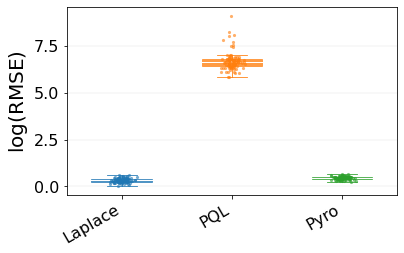

In [9]:
method_boxplot("beta_rmse", r"$\log(\mathrm{RMSE})$", value_transform=log_positive)




Compare test AUC across GLMM methods.


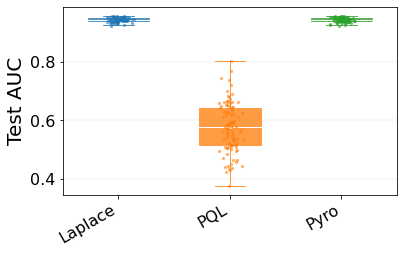

In [10]:
method_boxplot("test_auc", "Test AUC")


Compares the runtime distribution of each GLMM method.


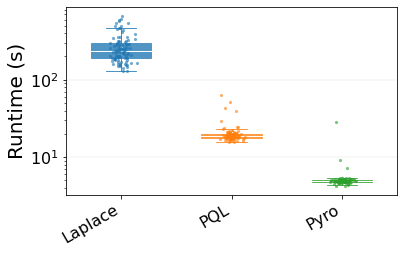

In [11]:
method_boxplot("time_sec", "Runtime (s)", log_y=True)
